# Intro: **Titanic Survival Prediction** Using CUDA

The goal of this experiment is to predict whether a passenger survived the Titanic disaster using CUDA in the pipeline.

##**Key Steps**
1. Exploratory Data Analysis
2. Data Preprocessing
3. Train-Test Split
4. Model Training (GPU)
5. Prediction
6. Evaluation

Done by: Siddharth S. (25901335)

# **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from numba import cuda
import math

# **Load Dataset**

In [ ]:
from google.colab import files
files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c titanic

In [5]:
!unzip titanic.zip

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [6]:
df = pd.read_csv('train.csv')

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **EDA**

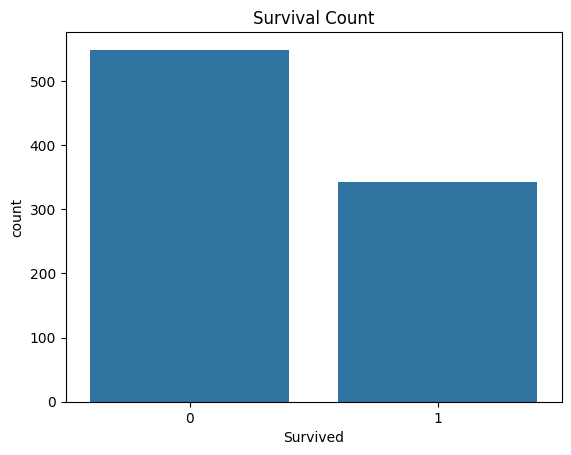

In [8]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

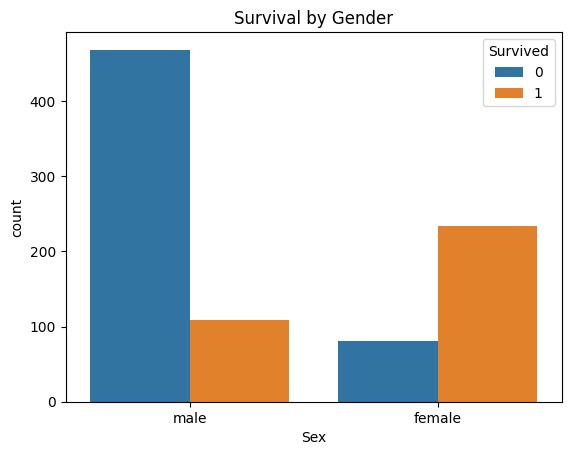

In [9]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

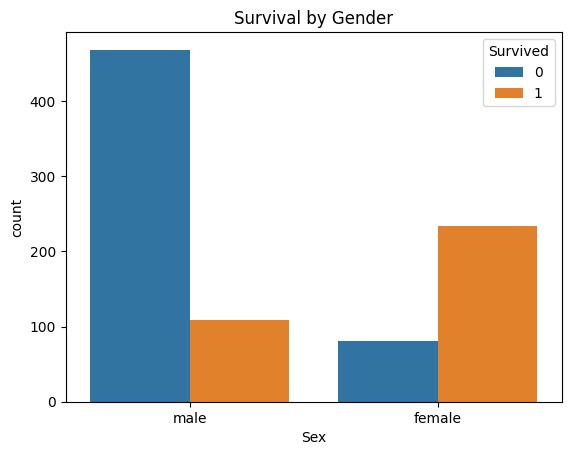

In [10]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

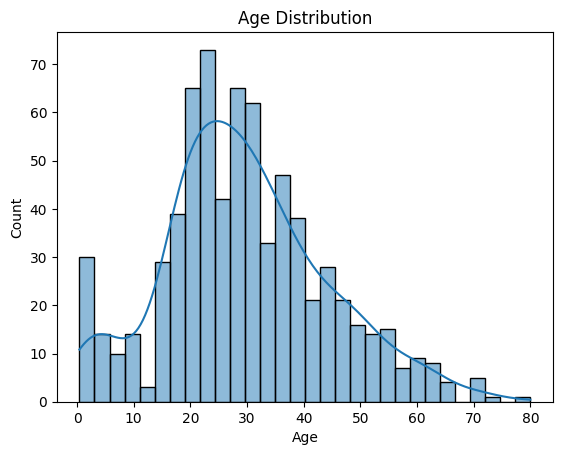

In [11]:
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

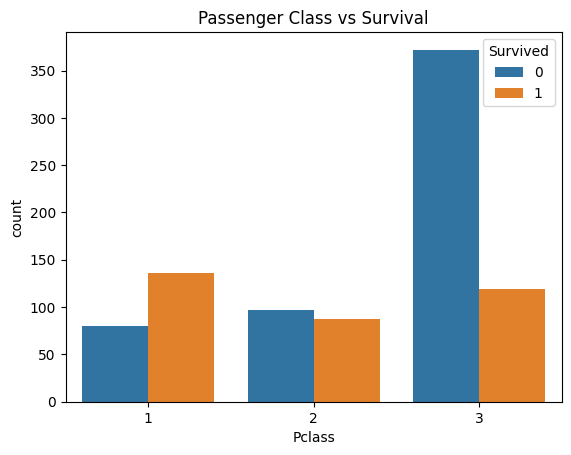

In [12]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# **Data Preprocessing**

In [ ]:
df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1) #Unnecessary columns

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}) #categorical -> numeric

# One-hot encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [32]:
X = df.drop(['Survived', 'PassengerId'], axis=1).values
y = df['Survived'].values

X = X.astype(np.float32)
y = y.astype(np.float32)

# **Feature Scaling**

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.astype(np.float32)

# **Test-Train Split**

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Logistic Regression (CUDA)**

## Sigmoid Function

In [35]:
@cuda.jit(device=True)
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

## Prediction Kernel

In [36]:
@cuda.jit
def predict_kernel(X, weights, bias, preds):
    i = cuda.grid(1)

    if i < X.shape[0]:
        z = 0.0
        for j in range(X.shape[1]):
            z += X[i, j] * weights[j]

        z += bias
        preds[i] = sigmoid(z)

## Gradient Kernel

In [37]:
@cuda.jit
def gradient_kernel(X, y, weights, bias, dw, db):
    i = cuda.grid(1)

    if i < X.shape[0]:
        z = 0.0
        for j in range(X.shape[1]):
            z += X[i, j] * weights[j]

        z += bias
        pred = sigmoid(z)

        error = pred - y[i]

        for j in range(X.shape[1]):
            cuda.atomic.add(dw, j, error * X[i, j])

        cuda.atomic.add(db, 0, error)

## Training Function

In [38]:
def train_gpu(X, y, lr=0.01, epochs=100):

    n_samples, n_features = X.shape

    weights = np.zeros(n_features)
    bias = np.array([0.0])

    d_X = cuda.to_device(X)
    d_y = cuda.to_device(y)

    for epoch in range(epochs):

        dw = np.zeros(n_features)
        db = np.zeros(1)

        d_dw = cuda.to_device(dw)
        d_db = cuda.to_device(db)

        threads_per_block = 256
        blocks = (n_samples + threads_per_block - 1) // threads_per_block

        gradient_kernel[blocks, threads_per_block](
            d_X, d_y, weights, bias[0], d_dw, d_db
        )

        dw = d_dw.copy_to_host()
        db = d_db.copy_to_host()

        weights -= lr * dw / n_samples
        bias -= lr * db / n_samples

    return weights, bias[0]

# **Training & Prediction**

In [39]:
weights, bias = train_gpu(X_train, y_train, lr=0.01, epochs=500)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:934: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


In [40]:
def predict(X, weights, bias):

    n_samples = X.shape[0]
    preds = np.zeros(n_samples)

    d_X = cuda.to_device(X)
    d_preds = cuda.to_device(preds)

    threads_per_block = 256
    blocks = (n_samples + threads_per_block - 1) // threads_per_block

    predict_kernel[blocks, threads_per_block](
        d_X, weights, bias, d_preds
    )

    preds = d_preds.copy_to_host()
    return (preds > 0.5).astype(int)

In [41]:
y_pred = predict(X_test, weights, bias)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:934: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


# **Evaluation**

In [42]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[85 20]
 [19 55]]


In [43]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.82      0.81      0.81       105
         1.0       0.73      0.74      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179

